<a href="https://colab.research.google.com/github/jayanth-talasri/Solar-irradiance-forecasting-using-deep-Learning-model-LSTM-/blob/main/solar_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
summer = pd.read_csv("/content/Summer_2004-2006.csv")
rainy = pd.read_csv("/content/Raini_2004-2006.csv")
winter = pd.read_csv("/content/Winter_2004-2006.csv")

print("Summer Shape:", summer.shape)
print("Rainy Shape:", rainy.shape)
print("Winter Shape:", winter.shape)

Summer Shape: (52416, 11)
Rainy Shape: (53136, 11)
Winter Shape: (51983, 11)


In [28]:
summer.columns = summer.columns.str.strip()

print(summer.columns)

Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')


In [27]:
print(summer.columns)
print(rainy.columns)
print(winter.columns)

Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')
Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')
Index(['Date Time', ' Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')


# **Summer Season Forecasting**

In [30]:
summer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date Time               52416 non-null  object 
 1   Time                    52416 non-null  object 
 2   Temperature             52416 non-null  float64
 3   Relative Humidity       52416 non-null  float64
 4   Pressure                52416 non-null  float64
 5   Wind speed              52416 non-null  float64
 6   Wind direction          52416 non-null  float64
 7   Rainfall                52416 non-null  float64
 8   Snowfall                52416 non-null  int64  
 9   Snow depth              52416 non-null  int64  
 10  Short-wave irradiation  52416 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 4.4+ MB


In [29]:
summer.isnull().sum()

,0
Date Time,0
Time,0
Temperature,0
Relative Humidity,0
Pressure,0
Wind speed,0
Wind direction,0
Rainfall,0
Snowfall,0
Snow depth,0


In [31]:
summer["Datetime"] = pd.to_datetime(
    summer["Date Time"].astype(str) + " " + summer["Time"].astype(str)
)

print(summer[["Date Time", "Time", "Datetime"]].head())

  Date Time  Time            Datetime
0  3/1/2004  0:00 2004-03-01 00:00:00
1  3/1/2004  0:10 2004-03-01 00:10:00
2  3/1/2004  0:20 2004-03-01 00:20:00
3  3/1/2004  0:30 2004-03-01 00:30:00
4  3/1/2004  0:40 2004-03-01 00:40:00


In [32]:
summer = summer.sort_values("Datetime")

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Datetime
0,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0,2004-03-01 00:00:00
1,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0,2004-03-01 00:10:00
2,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0,2004-03-01 00:20:00
3,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0,2004-03-01 00:30:00
4,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0,2004-03-01 00:40:00


In [33]:
summer.set_index("Datetime", inplace=True)

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation
Datetime,,,,,,,,,,,
2004-03-01 00:00:00,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0
2004-03-01 00:10:00,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0
2004-03-01 00:20:00,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0
2004-03-01 00:30:00,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0
2004-03-01 00:40:00,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0


In [34]:
summer["Hour"] = summer.index.hour
summer["Day"] = summer.index.day
summer["Month"] = summer.index.month

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Hour,Day,Month
Datetime,,,,,,,,,,,,,,
2004-03-01 00:00:00,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0,0,1,3
2004-03-01 00:10:00,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0,0,1,3
2004-03-01 00:20:00,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0,0,1,3
2004-03-01 00:30:00,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0,0,1,3
2004-03-01 00:40:00,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0,0,1,3


In [35]:
features = [
    "Temperature",
    "Relative Humidity",
    "Pressure",
    "Wind speed",
    "Wind direction",
    "Rainfall",
    "Snowfall",
    "Snow depth",
    "Hour",
    "Day",
    "Month"
]

In [36]:
target = "Short-wave irradiation"

In [37]:
X = summer[features]
y = summer[target]

print(X.head())
print(y.head())

                     Temperature  Relative Humidity  Pressure  Wind speed  \
Datetime                                                                    
2004-03-01 00:00:00       293.41              80.33   1005.01        2.74   
2004-03-01 00:10:00       293.37              79.86   1005.16        2.76   
2004-03-01 00:20:00       293.32              79.39   1005.31        2.77   
2004-03-01 00:30:00       293.27              78.92   1005.47        2.80   
2004-03-01 00:40:00       293.44              77.53   1005.62        2.86   

                     Wind direction  Rainfall  Snowfall  Snow depth  Hour  \
Datetime                                                                    
2004-03-01 00:00:00          300.73       0.0         0           0     0   
2004-03-01 00:10:00          302.82       0.0         0           0     0   
2004-03-01 00:20:00          304.89       0.0         0           0     0   
2004-03-01 00:30:00          306.92       0.0         0           0     0  

In [38]:
from sklearn.preprocessing import MinMaxScaler

In [39]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1))

In [40]:
print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)

X_scaled shape: (52416, 11)
y_scaled shape: (52416, 1)


In [41]:
X_scaled = pd.DataFrame(X_scaled, columns=features, index=summer.index)

y_scaled = pd.DataFrame(y_scaled, columns=[target], index=summer.index)

X_scaled.head()

,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Hour,Day,Month
Datetime,,,,,,,,,,,
2004-03-01 00:00:00,0.088855,0.802614,0.659333,0.181757,0.835845,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:10:00,0.087323,0.797029,0.664656,0.183099,0.841655,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:20:00,0.085408,0.791444,0.669979,0.183769,0.847409,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:30:00,0.083493,0.785859,0.675656,0.185781,0.853052,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:40:00,0.090004,0.769340,0.680979,0.189805,0.858195,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
sequence_length = 24

In [43]:
def create_sequences(X, y, sequence_length):

    X_sequences = []
    y_sequences = []

    for i in range(sequence_length, len(X)):

        X_sequences.append(
            X.iloc[i-sequence_length:i].values
        )

        y_sequences.append(
            y.iloc[i].values
        )

    return np.array(X_sequences), np.array(y_sequences)

In [44]:
X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    sequence_length
)

In [45]:
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (52392, 24, 11)
y_seq shape: (52392, 1)


In [46]:
train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test = y_seq[train_size:]

In [47]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (41913, 24, 11)
X_test shape: (10479, 24, 11)
y_train shape: (41913, 1)
y_test shape: (10479, 1)


Completed LSTM sequence generation

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [49]:
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Dense Layers
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [51]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,593 (213.25 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - loss: 0.0069 - mae: 0.0503 - val_loss: 0.0040 - val_mae: 0.0367
Epoch 2/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0041 - mae: 0.0382 - val_loss: 0.0031 - val_mae: 0.0336
Epoch 3/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - loss: 0.0035 - mae: 0.0350 - val_loss: 0.0032 - val_mae: 0.0328
Epoch 4/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - loss: 0.0031 - mae: 0.0325 - val_loss: 0.0026 - val_mae: 0.0297
Epoch 5/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - loss: 0.0028 - mae: 0.0308 - val_loss: 0.0020 - val_mae: 0.0258
Epoch 6/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - loss: 0.0026 - mae: 0.0295 - val_loss: 0.0019 - val_mae: 0.0247
Epoch 7/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - loss: 0.0024 - mae: 0.0282 - val_loss: 0.0016 - val_mae: 0.0211
Epoch 8/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - loss: 0.0022 - mae: 0.0271 - val_loss: 0.0016 - val_mae: 0.0224
Epoch 9/20
1179/1179 ━━━

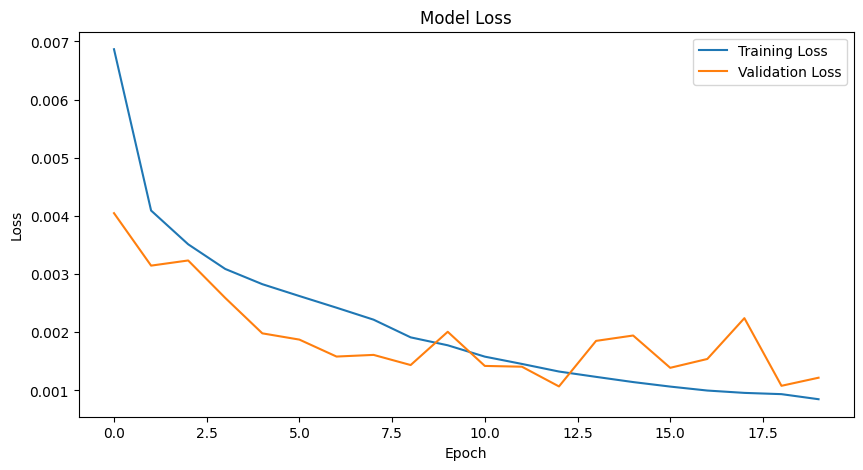

In [53]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [72]:
model.save("summer_lstm_model.h5")

Built and trained summer LSTM model

In [55]:
model.save("summer_lstm_model.keras")

In [56]:
y_pred = model.predict(X_test)

328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


In [57]:
y_pred_actual = target_scaler.inverse_transform(y_pred)

y_test_actual = target_scaler.inverse_transform(y_test)

In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [59]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)

mse = mean_squared_error(y_test_actual, y_pred_actual)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 6.148786325649724
RMSE: 10.582576701579008
R² Score: 0.940969494478412


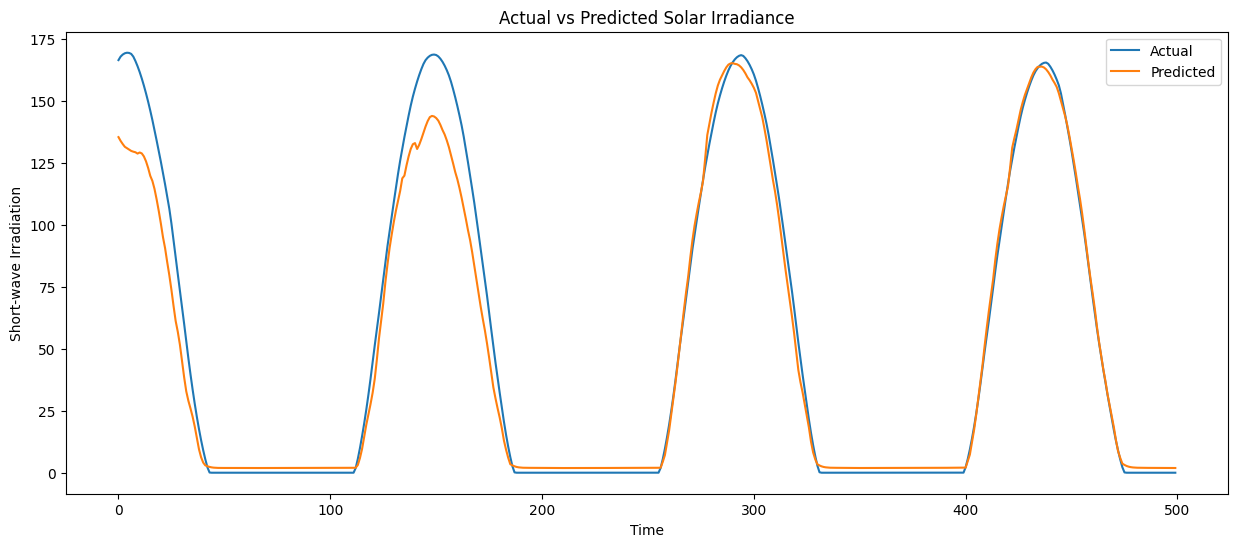

In [60]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual[:500],
    label="Actual"
)

plt.plot(
    y_pred_actual[:500],
    label="Predicted"
)

plt.title("Actual vs Predicted Solar Irradiance")

plt.xlabel("Time")

plt.ylabel("Short-wave Irradiation")

plt.legend()

plt.show()

In [61]:
plt.savefig("summer_prediction_plot.png")

<Figure size 640x480 with 0 Axes>

Completed summer model evaluation

In [62]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [63]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_summer_model.keras",
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [65]:
improved_model = Sequential()

# First LSTM Layer
improved_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

improved_model.add(Dropout(0.3))

# Second LSTM Layer
improved_model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

improved_model.add(Dropout(0.3))

# Dense Layers
improved_model.add(Dense(32, activation='relu'))

improved_model.add(Dense(16, activation='relu'))

# Output Layer
improved_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [66]:
improved_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [67]:
history_improved = improved_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - loss: 0.0080 - mae: 0.0529 - val_loss: 0.0041 - val_mae: 0.0373 - learning_rate: 0.0010
Epoch 2/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 58s 49ms/step - loss: 0.0040 - mae: 0.0370 - val_loss: 0.0034 - val_mae: 0.0345 - learning_rate: 0.0010
Epoch 3/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - loss: 0.0035 - mae: 0.0339 - val_loss: 0.0025 - val_mae: 0.0275 - learning_rate: 0.0010
Epoch 4/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - loss: 0.0032 - mae: 0.0319 - val_loss: 0.0026 - val_mae: 0.0300 - learning_rate: 0.0010
Epoch 5/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - loss: 0.0029 - mae: 0.0302 - val_loss: 0.0027 - val_mae: 0.0289 - learning_rate: 0.0010
Epoch 6/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - loss: 0.0027 - mae: 0.0290 - val_loss: 0.0019 - val_mae: 0.0234 - learning_rate: 0.0010
Epoch 7/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 58s 49ms/step - loss: 0.0025 - mae: 0.0280 - val_loss: 0.0026 - val_mae: 0.0299 - 

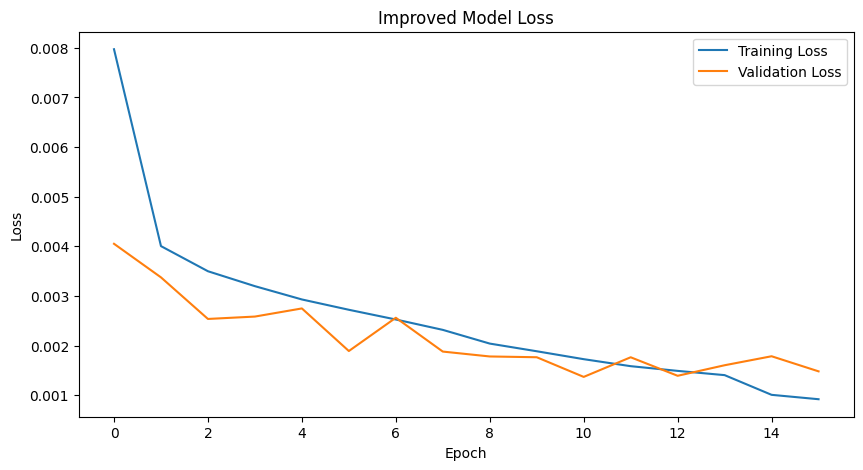

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)

plt.title("Improved Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

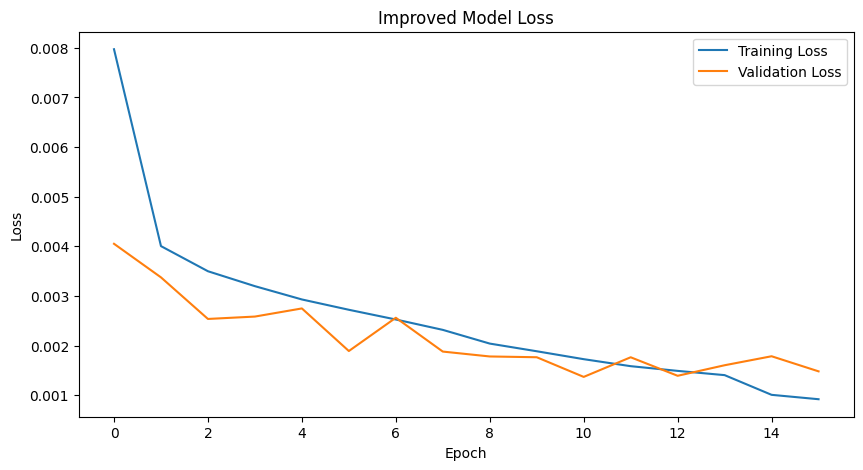

In [69]:
plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)

plt.title("Improved Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [70]:
import matplotlib.pyplot as plt

In [73]:
predictions = improved_model.predict(X_test)

print(predictions[:5])

328/328 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step
[[0.73121583]
 [0.72768164]
 [0.72366077]
 [0.7160066 ]
 [0.71012497]]


In [77]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 0.03268383725588776
RMSE: 0.06224182995066121
R2 Score: 0.9396132694515941


In [79]:
with open("metrics.txt", "w") as f:
    f.write(f"MAE: {mae}\n")
    f.write(f"RMSE: {rmse}\n")
    f.write(f"R2 Score: {r2}\n")

In [80]:
improved_model.save("improved_lstm_model.keras")

In [81]:
import os
os.makedirs("results/graphs", exist_ok=True)

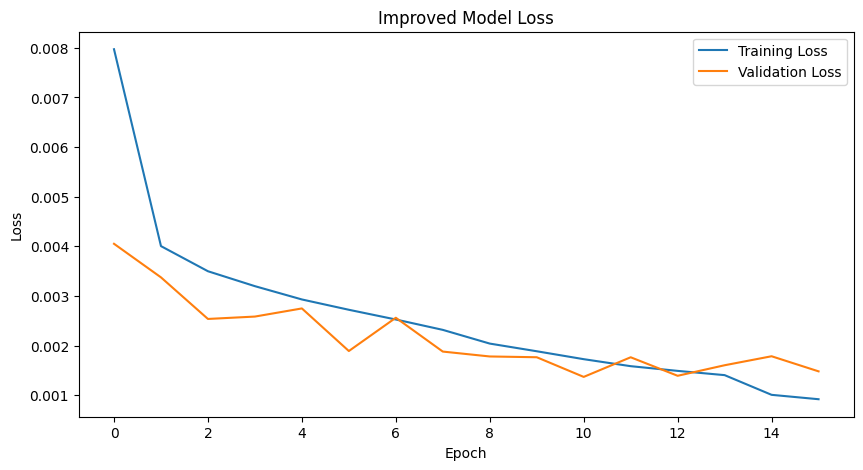

In [86]:
plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)

plt.title("Improved Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.savefig("results/graphs/Summer_loss_curve.png")

plt.show()

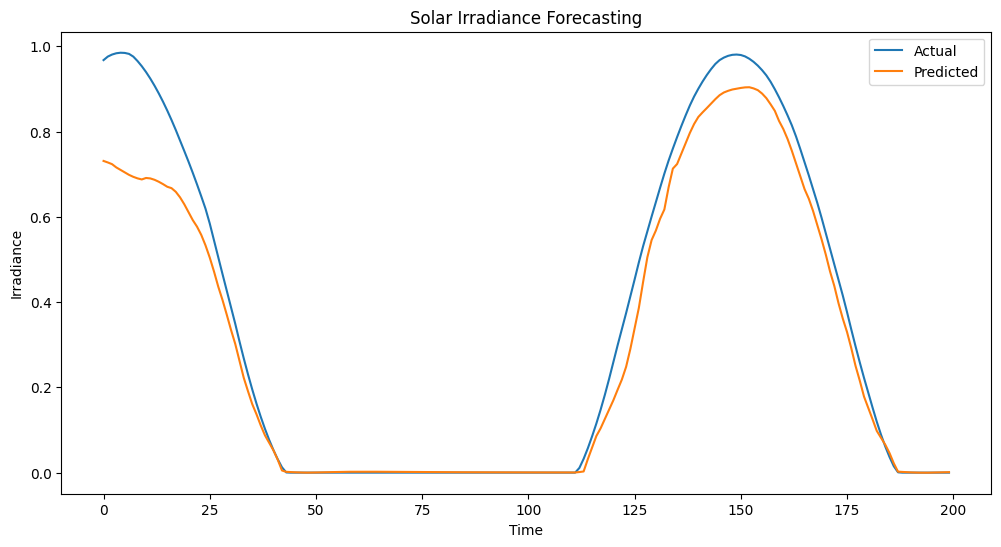

In [87]:
plt.figure(figsize=(12,6))

plt.plot(y_test[:200], label='Actual')

plt.plot(predictions[:200], label='Predicted')

plt.title("Solar Irradiance Forecasting")

plt.xlabel("Time")

plt.ylabel("Irradiance")

plt.legend()

plt.savefig("results/graphs/Summer_Prediction.png")

plt.show()

In [85]:
with open("results/metrics.txt", "w") as f:

    f.write(f"MAE: {mae}\n")

    f.write(f"RMSE: {rmse}\n")

    f.write(f"R2 Score: {r2}\n")

# **Rainy Season Forecasting**

In [89]:
rainy.columns = rainy.columns.str.strip()

print(rainy.columns)

Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')


In [91]:
rainy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53136 entries, 0 to 53135
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date Time               53136 non-null  object 
 1   Time                    53136 non-null  object 
 2   Temperature             53136 non-null  float64
 3   Relative Humidity       53136 non-null  float64
 4   Pressure                53136 non-null  float64
 5   Wind speed              53136 non-null  float64
 6   Wind direction          53136 non-null  float64
 7   Rainfall                53136 non-null  float64
 8   Snowfall                53136 non-null  int64  
 9   Snow depth              53136 non-null  int64  
 10  Short-wave irradiation  53136 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 4.5+ MB


In [94]:
rainy.isnull().sum()

,0
Date Time,0
Time,0
Temperature,0
Relative Humidity,0
Pressure,0
Wind speed,0
Wind direction,0
Rainfall,0
Snowfall,0
Snow depth,0
